# Find crossover points

This notebooks demonstrates the basics of finding crossovers (or intersections) between the flights or lines of an airborne survey.

In [1]:
%load_ext autoreload
%autoreload 2


import logging

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.io as pio
import verde as vd

import airbornegeo

# setup logging to get some additional info from the airbornegeo functions
logging.getLogger("airbornegeo").setLevel("INFO")
logging.basicConfig()
pio.renderers.default = "notebook"

## Load data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is downloaded and subset in the notebook `AGAP_magnetic_survey`.

In [2]:
data_df = pd.read_csv("data/AGAP_magnetic_survey_processed.csv")
data_df = data_df[
    [
        "easting",
        "northing",
        "height",
        "line",
        "unixtime",
        "distance_along_line",
        "mag",
    ]
]

data_df = data_df.rename(columns={"distance_along_line": "along_line_distance"})

# for testing limit number of lines
data_df = data_df[data_df.line.isin([149, 162, 47, 64, 80])]
data_df = data_df[
    ~(data_df.line == 47) | ~(data_df.along_line_distance.between(125e3, 134e3))
]
data_df = data_df[~(data_df.line == 64) | ~(data_df.along_line_distance > 497e3)]

# define line types: 0 for survey lines, 1 for tie lines
data_df["line_type"] = np.where(data_df.line >= 142, 1, 0)

data_df.head()

,easting,northing,height,line,unixtime,along_line_distance,mag,line_type
244630,1.078385e+06,324738.995745,4188.1,47,1.230251e+09,0.0,11.24,0
244631,1.078385e+06,324738.995745,4188.1,47,1.230251e+09,0.0,8.04,0
244632,1.078385e+06,324738.995745,4188.1,47,1.230251e+09,0.0,4.84,0
244633,1.078385e+06,324738.995745,4188.1,47,1.230251e+09,0.0,1.64,0
244634,1.078385e+06,324738.995745,4188.1,47,1.230251e+09,0.0,-1.56,0


This subset of the survey has 6 lines, 3 ~E-W survey lines, and 2 ~N-S tie lines. They are marked with the column `line_type`, with values of 0 or 1. You can see the line names using the  `unique()` method of pandas. We plot the data below and label each line with it's name / type.

In [3]:
data_df[data_df.line_type == 0].line.unique()

array([47, 64, 80])

In [4]:
data_df[data_df.line_type == 1].line.unique()

array([149, 162])

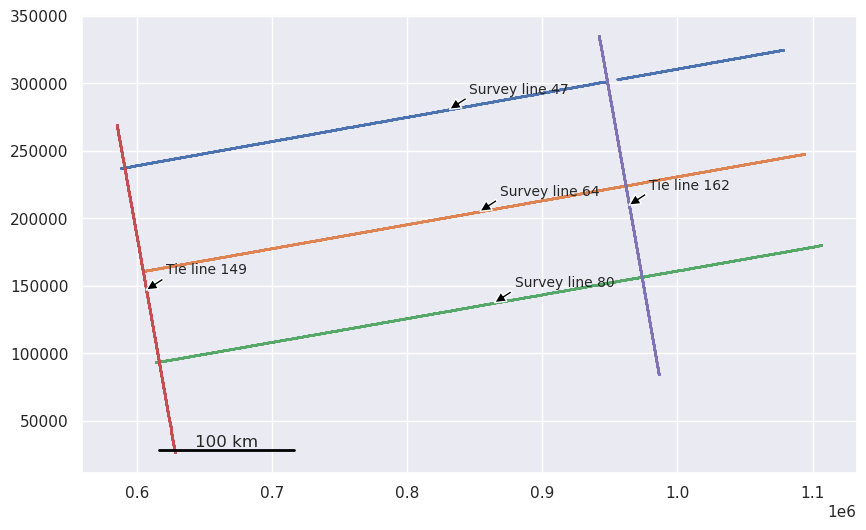

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))
for line_num, line_data in data_df.groupby("line"):
    # plot points
    ax.scatter(
        line_data.easting,
        line_data.northing,
        s=0.1,
    )
    # location for label
    label_point = line_data.iloc[len(line_data) // 2]
    # label string
    if line_data.line_type.iloc[0] == 0:
        line_name = f"Survey line {line_num}"
    else:
        line_name = f"Tie line {line_num}"
    ax.annotate(
        line_name,
        xy=(label_point.easting, label_point.northing),
        xycoords="data",
        xytext=(20, 20),
        textcoords="offset pixels",
        fontsize=10,
        arrowprops={
            "facecolor": "black",
            "headwidth": 8,
            "headlength": 8,
            "width": 2,
        },
        ha="left",
        va="center",
    )
ax.set_aspect("equal")
airbornegeo.add_scalebar(ax, 100e3)

## Calculate intersections of lines and ties
We want to calculate the theoretical intersection points between lines of different type. These types are denoted in the dataframe by the column 'line_type'. In our case, this column has values of 0 for E-W survey lines, and 1 for N-S tie lines. We referred to this as the "groups" method, since we only consider intersections between lines of two different types. 

If two lines of the same type were to cross, we would not count this as an intersect. In the next notebook we will demonstrate the "network" method, which considers all intersection between any combination of line, regardless of their type.

First we need to convert our dataframe into a geodataframe.

In [6]:
# convert dataframe into geodataframe
data_df = gpd.GeoDataFrame(
    data_df,
    geometry=gpd.points_from_xy(data_df.easting, data_df.northing),
    crs="EPSG:3031",
)

In [7]:
# calculate intersections between lines of different type using the 'groups' method
inters = airbornegeo.create_intersection_table(
    data_df,
    line_column="line",
    method="groups",
)
inters

Line pairs:   0%|          | 0/6 [00:00<?, ?it/s]

INFO:airbornegeo:found 5 intersections


,line1,line2,is_buffered,geometry,easting,northing,max_dist
0,47,149,False,POINT (590788 237703),590788.0,237703.0,12.785759
1,47,162,False,POINT (947875 301515),947875.0,301515.0,1470.097394
2,64,162,False,POINT (961606 224280),961606.0,224280.0,13.818089
3,80,149,False,POINT (616278 93894),616278.0,93894.0,8.205492
4,80,162,False,POINT (973552 156679),973552.0,156679.0,22.552582


The created intersection table contains a row for each theoretical intersection, which of the two lines the intersection is between, the coordinates of that intersection, as both a geometry object and the easting and northing coordinates. For now you can ignore the `is_buffered` column. The last column is `max_dist`. This shows the larger of the two distances from the theoretical intersection point to nearest data of each line. Below we show a map with these intersections colored by their `max_dist` values. 

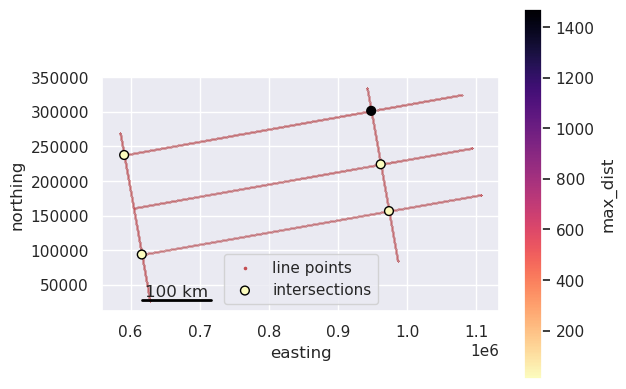

In [8]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    color="r",
    s=0.001,
    marker=".",
    label="line points",
)
ax.legend(markerscale=100)
inters.plot.scatter(
    "easting",
    "northing",
    c="max_dist",
    s=40,
    cmap="magma_r",
    marker="o",
    edgecolor="black",
    ax=ax,
    label="intersections",
)
airbornegeo.add_scalebar(ax, 100e3)
ax.set_aspect("equal")

To show what this `max_dist` column means, we can zoom in on the intersection between lines 47 and 162. The below map shows that the intersection point is very close to the nearest of the data points on the blue line (line 162), but due to a data gap in the red line (line 47), its is > 1 km from the nearest red point. Therefore, the `max_dist` value for this intersection is ~1.5 km.

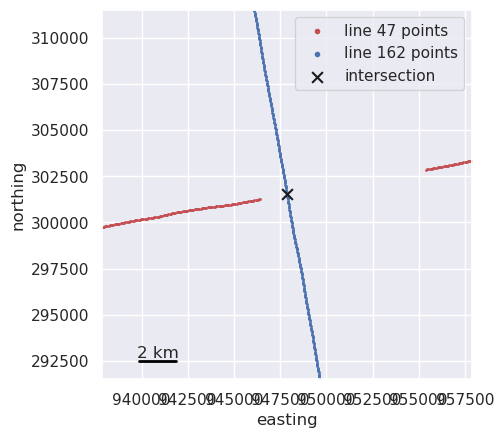

In [9]:
# zoom in on intersection
inter = inters[(inters.line1 == 47) & (inters.line2 == 162)].iloc[0]
reg = vd.get_region((inter.easting, inter.northing))
reg = vd.pad_region(reg, 10e3)

ax = data_df[data_df.line == inter.line1].plot.scatter(
    "easting",
    "northing",
    color="r",
    s=1,
    label=f"line {inter.line1} points",
)
ax = data_df[data_df.line == inter.line2].plot.scatter(
    "easting",
    "northing",
    color="b",
    s=1,
    ax=ax,
    label=f"line {inter.line2} points",
)
ax.legend(markerscale=3)
inters.plot.scatter(
    "easting",
    "northing",
    color="k",
    s=60,
    marker="x",
    ax=ax,
    label="intersection",
)
ax.set_xlim(reg[0], reg[1])
ax.set_ylim(reg[2], reg[3])

airbornegeo.add_scalebar(ax, 2000)
ax.set_aspect("equal")

## Buffer the ends of each line

Theoretically since there are 2 tie lines and 3 survey lines, there could be 6 intersection points. The plot below shows a zoom in where lines 64 and 149 theoretically may have intersected. Notice that line 64 ends just before crossing line 149. 

Since those two lines would cross if line 64 was just a ~100 meters longer, we can extend the ends of all lines to be longer so this is included as an intersection using the `buffer_dist` parameter.

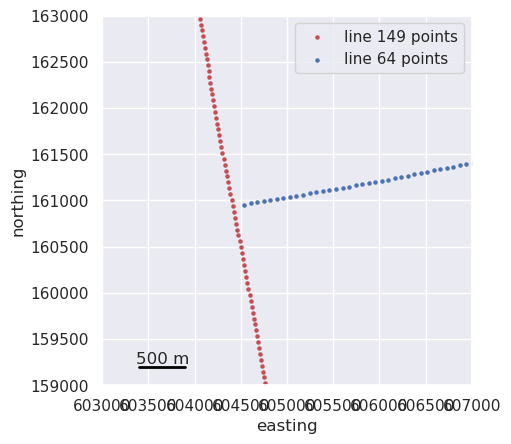

In [10]:
reg = (603e3, 607e3, 159e3, 163e3)

ax = data_df[data_df.line == 149].plot.scatter(
    "easting",
    "northing",
    color="r",
    s=5,
    label="line 149 points",
)
ax = data_df[data_df.line == 64].plot.scatter(
    "easting",
    "northing",
    color="b",
    s=5,
    ax=ax,
    label="line 64 points",
)

ax.legend()
ax.set_xlim(reg[0], reg[1])
ax.set_ylim(reg[2], reg[3])
ax.set_aspect("equal")

airbornegeo.add_scalebar(ax, 500)
ax.set_aspect("equal")

In [11]:
# calculate theoretical intersection points with a buffer
inters = airbornegeo.create_intersection_table(
    data_df,
    line_column="line",
    method="groups",
    buffer_dist=200,  # if intersection would be within 200 m of end of line, include it
)
inters

Line pairs:   0%|          | 0/6 [00:00<?, ?it/s]

INFO:airbornegeo:found 6 intersections


,line1,line2,is_buffered,geometry,easting,northing,max_dist
0,47,149,False,POINT (590788 237703),590788.0,237703.0,12.785759
1,47,162,False,POINT (947875 301515),947875.0,301515.0,1470.097394
2,64,149,True,POINT (604414 160932),604414.0,160932.0,125.587418
3,64,162,False,POINT (961606 224280),961606.0,224280.0,13.818089
4,80,149,False,POINT (616278 93894),616278.0,93894.0,8.205492
5,80,162,False,POINT (973552 156679),973552.0,156679.0,22.552582


Now you can see we've included this 6th intersection, between lines 64 and 149  and it was only ~125 m away from the end of line 64. You can see this below. Since the line was only included due to the buffer, it is labeled with a value of True for the 'is_buffered' column.

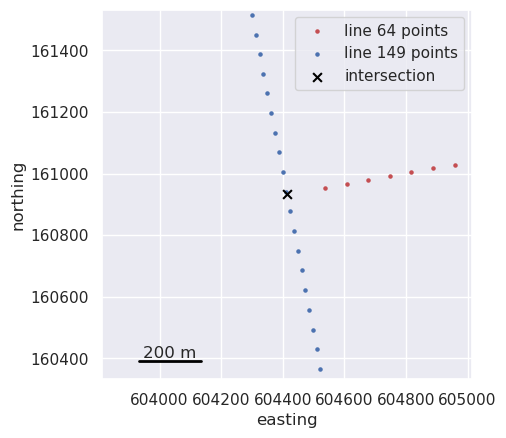

In [12]:
# zoom in on buffered intersection
inter = inters[inters.is_buffered].iloc[0]
reg = vd.get_region((inter.easting, inter.northing))
reg = vd.pad_region(reg, 600)

ax = data_df[data_df.line == inter.line1].plot.scatter(
    "easting",
    "northing",
    color="r",
    s=5,
    label=f"line {inter.line1} points",
)
ax = data_df[data_df.line == inter.line2].plot.scatter(
    "easting",
    "northing",
    color="b",
    s=5,
    ax=ax,
    label=f"line {inter.line2} points",
)
inters.plot.scatter(
    "easting",
    "northing",
    color="black",
    s=40,
    marker="x",
    ax=ax,
    label="intersection",
)
ax.legend()
ax.set_xlim(reg[0], reg[1])
ax.set_ylim(reg[2], reg[3])
ax.set_aspect("equal")

airbornegeo.add_scalebar(ax, 200)
ax.set_aspect("equal")

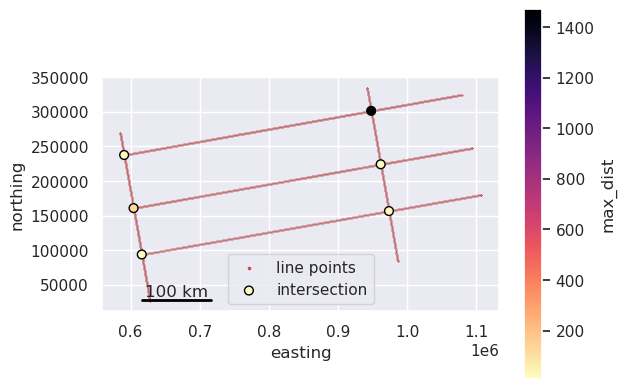

In [13]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    color="r",
    s=0.001,
    marker=".",
    label="line points",
)
ax.legend(markerscale=100)
inters.plot.scatter(
    "easting",
    "northing",
    c="max_dist",
    s=40,
    cmap="magma_r",
    marker="o",
    edgecolor="black",
    ax=ax,
    label="intersection",
)
ax.set_aspect("equal")

airbornegeo.add_scalebar(ax, 100e3)
ax.set_aspect("equal")

## Exclude intersections far away from data

Do to data gaps or buffering, some intersections points might be too far away from data to be considered useful. We can use the parameter `cutoff_dist` to exclude intersection which have too large of a `max_dist`. 

The below table and map shows using a 1km cutoff distance excluded the intersection between lines 47 and 162.

In [14]:
# calculate theoretical intersection points with a cutoff distance
inters = airbornegeo.create_intersection_table(
    data_df,
    line_column="line",
    method="groups",
    buffer_dist=200,
    cutoff_dist=1e3,  # if intersection is more than 1km from nearest data point, it is not included
)
inters

Line pairs:   0%|          | 0/6 [00:00<?, ?it/s]

INFO:airbornegeo:found 6 intersections
INFO:airbornegeo:removed 1 intersection point(s) with a max distance greater than 1 km


,line1,line2,is_buffered,geometry,easting,northing,max_dist
0,47,149,False,POINT (590788 237703),590788.0,237703.0,12.785759
1,64,149,True,POINT (604414 160932),604414.0,160932.0,125.587418
2,64,162,False,POINT (961606 224280),961606.0,224280.0,13.818089
3,80,149,False,POINT (616278 93894),616278.0,93894.0,8.205492
4,80,162,False,POINT (973552 156679),973552.0,156679.0,22.552582


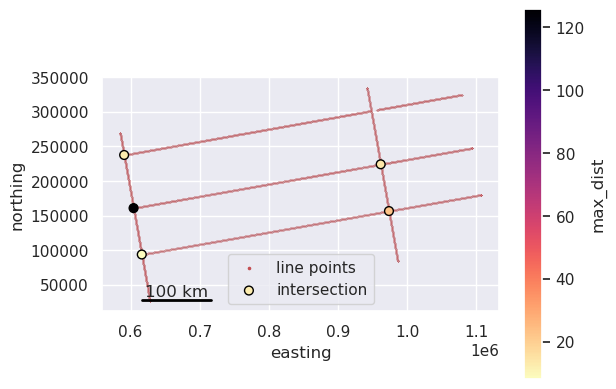

In [15]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    color="r",
    s=0.001,
    marker=".",
    label="line points",
)
ax.legend(markerscale=100)
inters.plot.scatter(
    "easting",
    "northing",
    c="max_dist",
    s=40,
    cmap="magma_r",
    marker="o",
    edgecolor="black",
    ax=ax,
    label="intersection",
)
ax.set_aspect("equal")

airbornegeo.add_scalebar(ax, 100e3)
ax.set_aspect("equal")

## Manually exclude intersections

We can also manually exclude intersections if we know they have issues. You can supply tuples of pairs of line numbers, or if you want to exclude an entire line, just supply the individual line number.

In [16]:
# calculate theoretical intersection points
inters = airbornegeo.create_intersection_table(
    data_df,
    line_column="line",
    method="groups",
    exclude_ints=[
        [47],  # exclude all intersections of line 47
        [80, 149],  # exclude the intersection of 80 and 149
    ],
)
inters

Line pairs:   0%|          | 0/6 [00:00<?, ?it/s]

INFO:airbornegeo:found 5 intersections
INFO:airbornegeo:manually omitted 3 intersections points


,line1,line2,is_buffered,geometry,easting,northing,max_dist
0,64,162,False,POINT (961606 224280),961606.0,224280.0,13.818089
1,80,162,False,POINT (973552 156679),973552.0,156679.0,22.552582


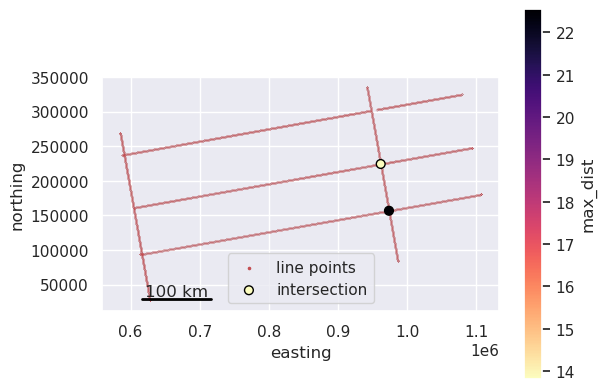

In [17]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    color="r",
    s=0.001,
    marker=".",
    label="line points",
)
ax.legend(markerscale=100)
inters.plot.scatter(
    "easting",
    "northing",
    c="max_dist",
    s=40,
    cmap="magma_r",
    marker="o",
    edgecolor="black",
    ax=ax,
    label="intersection",
)
ax.set_aspect("equal")

airbornegeo.add_scalebar(ax, 100e3)
ax.set_aspect("equal")